# Neural Network ONNX Models for Alquimia Shape Testing

This notebook trains a PyTorch neural-network regressor for PHREEQC simulation data and exports ONNX models with several input/output signatures for Alquimia testing.

Inputs: `specified_pH`, `input_Zn_mol_L`

Outputs: `SURF-Zn++`, `SURF-H+`

A key goal is verifying that preprocessing is integrated into one ONNX graph. The exported models accept physical-scale chemical inputs directly, standardize inside the graph, run the neural network, unstandardize inside the graph, and return physical-scale surface outputs.

In [120]:
import pandas as pd
import numpy as np
df = pd.read_csv('../data/phreeqc_example8_all_simulations.csv')
df = df.dropna()
df

,sim,specified_pH,input_Zn_mol_L,time_days,pH,TOT-H+,TOT-Zn++,TOT-Na+,TOT-NO3-,TOT-Fe+++,...,Zn(OH)4--,ZnOH+,>FeOH_str,>FeOH_weak,>FeO-_str,>FeOH2+_str,>FeOHZn+_str,>FeO-_w,>FeOH2+_w,>FeOHZn+_w
0,ph5p00_zn1e-07,5.00,1.000000e-07,365.0,4.996352,1.210717e-05,9.960889e-08,0.099988,0.1,2.598771e-09,...,2.735187e-29,5.632359e-12,2.460044e-06,0.000098,4.406788e-08,3.146036e-06,3.753899e-10,0.000002,0.000126,1.572430e-11
1,ph5p25_zn1e-07,5.25,1.000000e-07,365.0,5.246200,6.809139e-06,9.893112e-08,0.099993,0.1,4.630258e-10,...,2.712653e-28,9.943835e-12,2.842421e-06,0.000114,6.756176e-08,2.739528e-06,1.025903e-09,0.000003,0.000110,4.297787e-11
2,ph5p50_zn1e-07,5.50,1.000000e-07,365.0,5.496210,3.826110e-06,9.713167e-08,0.099996,0.1,8.246151e-11,...,2.663356e-27,1.736033e-11,3.181967e-06,0.000127,9.795688e-08,2.367862e-06,2.752968e-09,0.000004,0.000095,1.153646e-10
3,ph5p75_zn1e-07,5.75,1.000000e-07,365.0,5.746311,2.145994e-06,9.255899e-08,0.099998,0.1,1.469433e-11,...,2.539981e-26,2.942092e-11,3.470281e-06,0.000139,1.353890e-07,2.037727e-06,7.141510e-09,0.000005,0.000082,2.995013e-10
4,ph6p00_zn1e-07,6.00,1.000000e-07,365.0,5.996474,1.197283e-06,8.206505e-08,0.099999,0.1,2.622948e-12,...,2.254839e-25,4.639287e-11,3.703137e-06,0.000149,1.794382e-07,1.750752e-06,1.721183e-08,0.000007,0.000070,7.231203e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,ph7p00_zn1e-04,7.00,1.000000e-04,365.0,7.000390,-4.445536e-07,7.142152e-05,0.099858,0.1,2.813095e-15,...,2.023826e-18,4.052048e-07,3.973951e-08,0.000156,5.598490e-09,6.462107e-09,5.598739e-06,0.000022,0.000025,2.297974e-05
74,ph7p25_zn1e-04,7.25,1.000000e-04,365.0,7.250868,-8.165159e-07,5.770633e-05,0.099885,0.1,5.383830e-16,...,1.634481e-17,5.800511e-07,2.305543e-08,0.000144,4.783967e-09,2.545413e-09,5.620155e-06,0.000030,0.000016,3.667352e-05
75,ph7p50_zn1e-04,7.50,1.000000e-04,365.0,7.501363,-1.320143e-06,4.378814e-05,0.099914,0.1,1.079679e-16,...,1.234675e-16,7.765502e-07,1.473125e-08,0.000126,4.646841e-09,1.069847e-09,5.630091e-06,0.000040,0.000009,5.058177e-05
76,ph7p75_zn1e-04,7.75,1.000000e-04,365.0,7.751892,-2.058269e-06,3.134436e-05,0.099939,0.1,2.309149e-17,...,8.725713e-16,9.724032e-07,1.000640e-08,0.000107,4.775784e-09,4.802985e-10,5.635277e-06,0.000051,0.000005,6.302036e-05


In [121]:
df = df.rename(columns={'specified_pH':'input_pH','input_Zn_mol_L':'zn','SURF-H+':'h_sorbed','SURF-Zn++':'zn_sorbed'})
df['h']=10**(-df['input_pH'])
df


,sim,input_pH,zn,time_days,pH,TOT-H+,TOT-Zn++,TOT-Na+,TOT-NO3-,TOT-Fe+++,...,ZnOH+,>FeOH_str,>FeOH_weak,>FeO-_str,>FeOH2+_str,>FeOHZn+_str,>FeO-_w,>FeOH2+_w,>FeOHZn+_w,h
0,ph5p00_zn1e-07,5.00,1.000000e-07,365.0,4.996352,1.210717e-05,9.960889e-08,0.099988,0.1,2.598771e-09,...,5.632359e-12,2.460044e-06,0.000098,4.406788e-08,3.146036e-06,3.753899e-10,0.000002,0.000126,1.572430e-11,1.000000e-05
1,ph5p25_zn1e-07,5.25,1.000000e-07,365.0,5.246200,6.809139e-06,9.893112e-08,0.099993,0.1,4.630258e-10,...,9.943835e-12,2.842421e-06,0.000114,6.756176e-08,2.739528e-06,1.025903e-09,0.000003,0.000110,4.297787e-11,5.623413e-06
2,ph5p50_zn1e-07,5.50,1.000000e-07,365.0,5.496210,3.826110e-06,9.713167e-08,0.099996,0.1,8.246151e-11,...,1.736033e-11,3.181967e-06,0.000127,9.795688e-08,2.367862e-06,2.752968e-09,0.000004,0.000095,1.153646e-10,3.162278e-06
3,ph5p75_zn1e-07,5.75,1.000000e-07,365.0,5.746311,2.145994e-06,9.255899e-08,0.099998,0.1,1.469433e-11,...,2.942092e-11,3.470281e-06,0.000139,1.353890e-07,2.037727e-06,7.141510e-09,0.000005,0.000082,2.995013e-10,1.778279e-06
4,ph6p00_zn1e-07,6.00,1.000000e-07,365.0,5.996474,1.197283e-06,8.206505e-08,0.099999,0.1,2.622948e-12,...,4.639287e-11,3.703137e-06,0.000149,1.794382e-07,1.750752e-06,1.721183e-08,0.000007,0.000070,7.231203e-10,1.000000e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,ph7p00_zn1e-04,7.00,1.000000e-04,365.0,7.000390,-4.445536e-07,7.142152e-05,0.099858,0.1,2.813095e-15,...,4.052048e-07,3.973951e-08,0.000156,5.598490e-09,6.462107e-09,5.598739e-06,0.000022,0.000025,2.297974e-05,1.000000e-07
74,ph7p25_zn1e-04,7.25,1.000000e-04,365.0,7.250868,-8.165159e-07,5.770633e-05,0.099885,0.1,5.383830e-16,...,5.800511e-07,2.305543e-08,0.000144,4.783967e-09,2.545413e-09,5.620155e-06,0.000030,0.000016,3.667352e-05,5.623413e-08
75,ph7p50_zn1e-04,7.50,1.000000e-04,365.0,7.501363,-1.320143e-06,4.378814e-05,0.099914,0.1,1.079679e-16,...,7.765502e-07,1.473125e-08,0.000126,4.646841e-09,1.069847e-09,5.630091e-06,0.000040,0.000009,5.058177e-05,3.162278e-08
76,ph7p75_zn1e-04,7.75,1.000000e-04,365.0,7.751892,-2.058269e-06,3.134436e-05,0.099939,0.1,2.309149e-17,...,9.724032e-07,1.000640e-08,0.000107,4.775784e-09,4.802985e-10,5.635277e-06,0.000051,0.000005,6.302036e-05,1.778279e-08


In [122]:
input_columns = ['h','zn']
output_columns = ['h_sorbed', 'zn_sorbed']
X = df[input_columns]
y = df[output_columns]

In [123]:
X

,h,zn
0,1.000000e-05,1.000000e-07
1,5.623413e-06,1.000000e-07
2,3.162278e-06,1.000000e-07
3,1.778279e-06,1.000000e-07
4,1.000000e-06,1.000000e-07
...,...,...
73,1.000000e-07,1.000000e-04
74,5.623413e-08,1.000000e-04
75,3.162278e-08,1.000000e-04
76,1.778279e-08,1.000000e-04


In [124]:
y

,h_sorbed,zn_sorbed
0,0.000127,3.911142e-10
1,0.000110,1.068880e-09
2,0.000093,2.868332e-09
3,0.000078,7.441011e-09
4,0.000065,1.793495e-08
...,...,...
73,-0.000025,2.857848e-05
74,-0.000056,4.229367e-05
75,-0.000087,5.621186e-05
76,-0.000115,6.865564e-05


## Visualize the Data

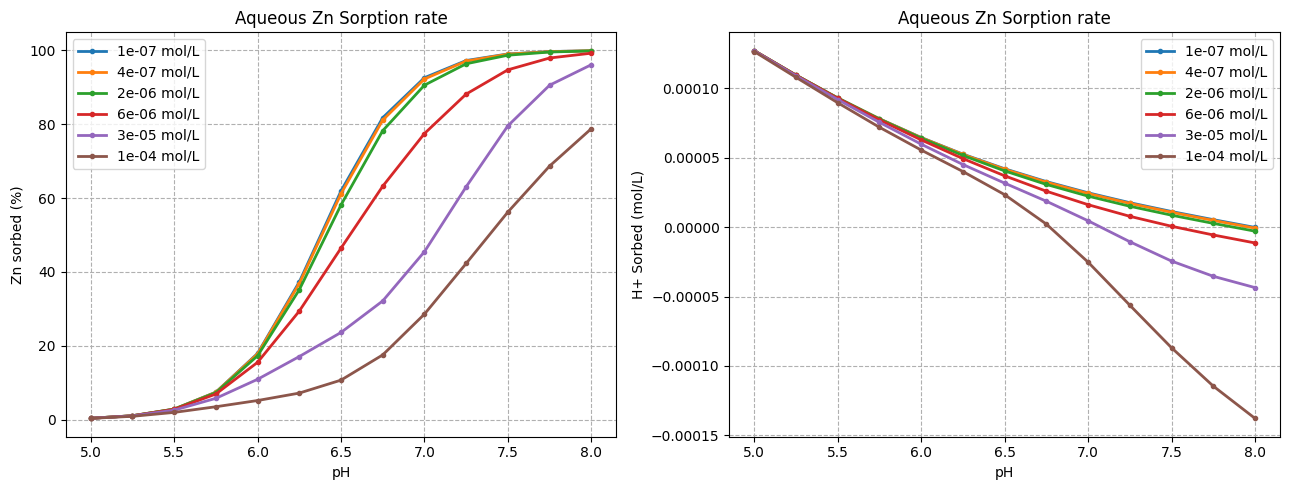

In [125]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13,5))
zn_values = df['zn'].unique()

for zn in zn_values:
    subset = df[df['zn'] == zn]
    # print(f'subset: {subset}')
    
    zn_sorbed_percent = (subset['zn_sorbed'] / zn) * 100
    
    axes[0].plot(
        subset['input_pH'],
        zn_sorbed_percent,
        marker='.',
        linewidth=2,
        label=f'{zn:.0e} mol/L'
    )
    
axes[0].set_title('Aqueous Zn Sorption rate')
axes[0].set_xlabel('pH')
axes[0].set_ylabel('Zn sorbed (%)')
axes[0].grid(True, linestyle='--')
axes[0].legend()

for zn in zn_values:
    subset = df[df['zn'] == zn]
    # print(f'subset: {subset}')
    
    axes[1].plot(
        subset['input_pH'],
        subset['h_sorbed'],
        marker='.',
        linewidth=2,
        label=f'{zn:.0e} mol/L'
    )
    
axes[1].set_title('Aqueous Zn Sorption rate')
axes[1].set_xlabel('pH')
axes[1].set_ylabel('H+ Sorbed (mol/L)')
axes[1].grid(True, linestyle='--')
axes[1].legend()


    

plt.tight_layout()
plt.show()

## Train Test Splitting

In [126]:
from sklearn.model_selection import train_test_split

X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor = train_test_split(X, y, test_size=0.2, random_state=270)

## Add the noisy to the data to get more data
keep the Mean = 1, Variance = sigma (0.01)

In [127]:
rng = np.random.default_rng(270)
sigma = 0.01  # Standard deviation
number = 120

noisy_inputs = [X_train_tensor.to_numpy()]
noisy_inputs

for _ in range(number):
    noise = rng.normal(-0.5 * sigma**2, sigma, X_train_tensor.shape)   # Generate the noise
    # print(f'Noise: {noise}')
    noisy_inputs.append(X_train_tensor.to_numpy() * np.exp(noise)) # Add the noisy data in the list

X_train_noise = np.vstack(noisy_inputs) # Stack vertically
y_train_noise = np.tile(y_train_tensor.to_numpy(), (number + 1, 1))    # Related label should change as well

## Data preprocessing (Standardization)

In [128]:
from sklearn.preprocessing import StandardScaler

x_scalar = StandardScaler()
y_scalar = StandardScaler()

x_scalar.fit(X_train_tensor)
y_scalar.fit(y_train_tensor)

# For the train set
X_train_scale = x_scalar.transform(X_train_noise)
y_train_scale = y_scalar.transform(y_train_noise)

# For the test set
X_test_scale = x_scalar.transform(X_test_tensor)
y_test_scale = y_scalar.transform(y_test_tensor)

/home/zfeng3/miniconda3/envs/geochem_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/zfeng3/miniconda3/envs/geochem_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [129]:
import torch
X_train_tensor = torch.tensor(X_train_scale, dtype=torch.float64)
y_train_tensor = torch.tensor(y_train_scale, dtype=torch.float64)

X_test_tensor = torch.tensor(X_test_scale, dtype=torch.float64)
y_test_tensor = torch.tensor(y_test_scale, dtype=torch.float64)

## Define the NN regressor

In [130]:
import torch.nn as nn

torch.set_default_dtype(torch.float64)  # Set the global precision as Double
class ChemicalRegressor(nn.Module):
    def __init__(self, layer, p=0.1, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)

        self.layers = nn.ModuleList()
        for i in range(len(layer) - 1):
            self.layers.append(nn.Linear(layer[i], layer[i + 1]))
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=p)

    def forward(self, x):
        for i in range(len(self.layers) - 1):
            x = self.relu(self.layers[i](x))
            x = self.dropout(x) # Prevent overfitting (Shut down 10% neurons)
            

        x = self.layers[-1](x)

        return x

## Train the Model

In [131]:
def train_model(model, X_train, y_train, X_test, y_test, epochs = 100, lr=0.01):
    # Define the loss function
    criterion = nn.MSELoss()
    
    # Define optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    
    
    history = {'train_loss':[], 'val_loss':[]}
    
    for epoch in range(epochs):
        model.train()
        val_loss = 0
        train_loss = 0
                
        # Clear the grad from the last round
        optimizer.zero_grad()
        
        # Forward propagation
        outputs = model.forward(X_train)    # Tuple
        
        # Calculate the loss
        loss = criterion(outputs, y_train)
        
        # Backward propagation
        loss.backward()
        
        # Update the weight
        optimizer.step()
        
        train_loss = loss.item()
        
        # Validation
        model.eval()
        
        # Stop updating the grad
        with torch.no_grad():
            test_output = model(X_test)
            v_loss = criterion(test_output, y_test)
            val_loss = v_loss.item()
            
    
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        print(f'Epoch {epoch + 1} Loss: {train_loss:.4f}')
        
    return model, history
        

In [132]:
model = ChemicalRegressor([2, 512, 128, 64, 2])

In [133]:
model, history = train_model(model, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, epochs=50)

Epoch 1 Loss: 1.0094
Epoch 2 Loss: 0.7573
Epoch 3 Loss: 1.7505
Epoch 4 Loss: 0.6334
Epoch 5 Loss: 0.6750
Epoch 6 Loss: 0.6766
Epoch 7 Loss: 0.6565
Epoch 8 Loss: 0.6238
Epoch 9 Loss: 0.5773
Epoch 10 Loss: 0.5305
Epoch 11 Loss: 0.4909
Epoch 12 Loss: 0.4482
Epoch 13 Loss: 0.4031
Epoch 14 Loss: 0.3719
Epoch 15 Loss: 0.3460
Epoch 16 Loss: 0.3324
Epoch 17 Loss: 0.3080
Epoch 18 Loss: 0.3008
Epoch 19 Loss: 0.2788
Epoch 20 Loss: 0.2769
Epoch 21 Loss: 0.2614
Epoch 22 Loss: 0.2387
Epoch 23 Loss: 0.2269
Epoch 24 Loss: 0.2169
Epoch 25 Loss: 0.2107
Epoch 26 Loss: 0.1946
Epoch 27 Loss: 0.1943
Epoch 28 Loss: 0.1843
Epoch 29 Loss: 0.1932
Epoch 30 Loss: 0.1917
Epoch 31 Loss: 0.1935
Epoch 32 Loss: 0.1540
Epoch 33 Loss: 0.1591
Epoch 34 Loss: 0.1869
Epoch 35 Loss: 0.1470
Epoch 36 Loss: 0.1475
Epoch 37 Loss: 0.1674
Epoch 38 Loss: 0.1432
Epoch 39 Loss: 0.1425
Epoch 40 Loss: 0.1481
Epoch 41 Loss: 0.1257
Epoch 42 Loss: 0.1418
Epoch 43 Loss: 0.1388
Epoch 44 Loss: 0.1185
Epoch 45 Loss: 0.1336
Epoch 46 Loss: 0.11

## Plot the Result

In [134]:
def plot_result(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='Train Loss',color='blue', linewidth=3)
    plt.plot(history['val_loss'], label='Validation Loss', color='green', linewidth=3)
    
    plt.yscale('log')
    plt.grid(True, linestyle='--')
    
    plt.title('Model Training History (Log Scale)')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss(log Scale)')
    
    plt.legend()
    
    
    plt.tight_layout()
    plt.show()

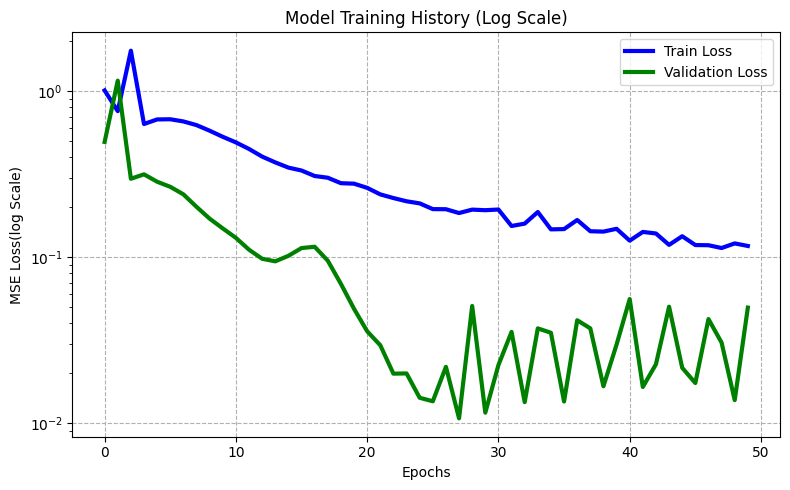

In [135]:
plot_result(history)

## Evaluate the Model

In [136]:
# Switch to evaluation
model.eval()

with torch.no_grad():
    prediction_scale_tensor = model(X_test_tensor)

prediction_scale = prediction_scale_tensor.numpy()

# Inverse standardization
prediction = y_scalar.inverse_transform(prediction_scale)


true_scale = y_test_scale
true_result = y_scalar.inverse_transform(true_scale)

print(prediction)
print(true_result)
print(type(true_result))

[[ 2.72187959e-05  6.76650847e-06]
 [ 1.37620691e-05  1.48343309e-06]
 [-9.00149038e-05  5.72272276e-05]
 [ 6.46554961e-05  6.07447718e-07]
 [ 7.50986164e-05  7.31136757e-07]
 [ 2.78219943e-06  5.24592078e-06]
 [ 6.51464814e-05  2.63703515e-06]
 [ 6.20307025e-05  1.26835342e-06]
 [ 1.74045721e-05  1.58160373e-06]
 [ 8.53147391e-06  2.45380861e-06]
 [ 3.83788121e-05  1.59176075e-06]
 [ 5.18640773e-05  1.00330937e-06]
 [ 1.46830942e-04 -1.26910432e-06]
 [ 1.22827757e-04  1.69217237e-07]
 [ 1.02072102e-04  7.41079062e-07]
 [ 2.65642865e-05  5.41601088e-07]]
[[ 3.17520340e-05  5.93235754e-06]
 [ 1.71409936e-05  3.86431684e-07]
 [-5.62458399e-05  4.22936742e-05]
 [ 6.45044505e-05  7.08813867e-08]
 [ 7.73262937e-05  4.38413473e-07]
 [ 6.50561356e-07  5.97512953e-06]
 [ 7.55496353e-05  1.45319196e-06]
 [ 6.29071503e-05  9.79483587e-07]
 [ 2.23745711e-05  1.43505109e-06]
 [ 2.73548795e-06  1.57718724e-06]
 [ 3.70195601e-05  2.93026017e-06]
 [ 5.17077480e-05  5.57541272e-07]
 [ 1.26562205e-04  

In [138]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
for i, name in enumerate(output_columns):
    true = true_result[:,i]
    y_predict = prediction[:,i]
    
    r2 = r2_score(true, y_predict)
    mae = mean_absolute_error(true, y_predict)
    rmse = np.sqrt(mean_squared_error(true, y_predict))
    
    print(f'======== Evaluation Results: {name} ========')
    print(f"R² : {r2:.4f}")
    print(f"MAE : {mae:.4e}")  
    print(f"RMSE : {rmse:.4e}\n")

======== Evaluation Results: h_sorbed ========
R² : 0.9475
MAE : 6.7527e-06
RMSE : 1.0825e-05

======== Evaluation Results: zn_sorbed ========
R² : 0.8556
MAE : 1.6023e-06
RMSE : 3.8198e-06



## Save the Model

In [141]:
# torch.save(model.state_dict(),'../models/zn_h_regressor.pt')

## Save the Scaler

In [ ]:
# import joblib
# import os
# save_dir = '../models/zn_h_regressor/'
# os.makedirs(save_dir, exist_ok=True)
# joblib.dump(x_scalar, os.path.join(save_dir,'x_scalar.joblib'))
# joblib.dump(y_scalar,os.path.join(save_dir,'y_scalar.joblib'))

['../models/zn_h_regressor/y_scalar.joblib']